# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [10]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [11]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [12]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [14]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [15]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [16]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [17]:
print("LabelEncoder (sex): 0=female, 1=male → un solo número por fila")
print(data[['sex', 'sex_label']].drop_duplicates().sort_values('sex_label'))
print("\nOneHotEncoder (embarked): una columna por categoría (S, C, Q)")
print(data[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].head())

LabelEncoder (sex): 0=female, 1=male → un solo número por fila
      sex  sex_label
1  female          0
0    male          1

OneHotEncoder (embarked): una columna por categoría (S, C, Q)
  embarked  embarked_C  embarked_Q  embarked_S
0        S       False       False        True
1        C        True       False       False
2        S       False       False        True
3        S       False       False        True
4        S       False       False        True


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

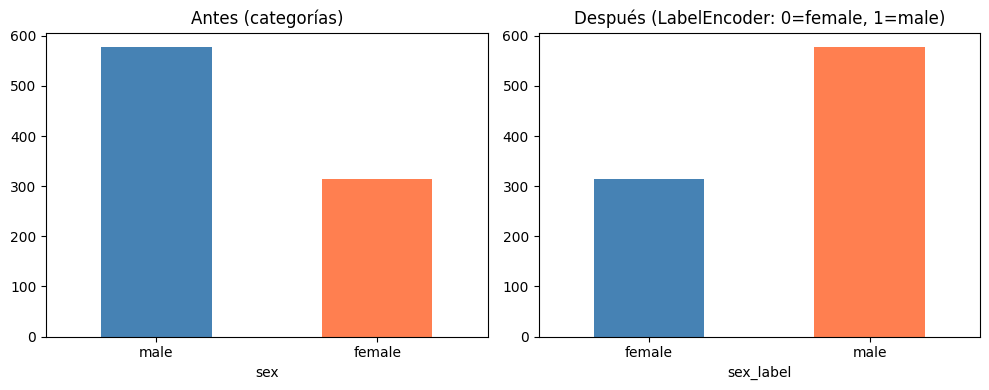

In [18]:
# Frecuencias de 'sex' antes (categórica) y después (numérica con LabelEncoder)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
data['sex'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title("Antes (categorías)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

data['sex_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title("Después (LabelEncoder: 0=female, 1=male)")
axes[1].set_xticklabels(['female', 'male'], rotation=0)
plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [19]:
# OneHotEncoder para 'class' (sklearn) — ya importado arriba
enc_class = OneHotEncoder(sparse_output=False)
class_encoded = enc_class.fit_transform(data[['class']])
cols_class = enc_class.get_feature_names_out(['class'])
data_class_oh = pd.DataFrame(class_encoded, columns=cols_class, index=data.index)
data = pd.concat([data, data_class_oh], axis=1)

print("Columnas creadas para 'class':", list(cols_class))
print(data[['class', 'class_First', 'class_Second', 'class_Third']].head())
print("\nVentaja vs LabelEncoder: 'class' no tiene orden real (First/Second/Third);")
print("OneHot no impone orden y evita que el modelo interprete 2 como 'el doble' de 1.")

Columnas creadas para 'class': ['class_First', 'class_Second', 'class_Third']
   class  class_First  class_Second  class_Third
0  Third          0.0           0.0          1.0
1  First          1.0           0.0          0.0
2  Third          0.0           0.0          1.0
3  First          1.0           0.0          0.0
4  Third          0.0           0.0          1.0

Ventaja vs LabelEncoder: 'class' no tiene orden real (First/Second/Third);
OneHot no impone orden y evita que el modelo interprete 2 como 'el doble' de 1.


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [20]:
print("Para aprendizaje automático conviene OneHotEncoder (o get_dummies) en categorías nominales:")
print("- No asume orden entre categorías (evita que 'Third' > 'First' numéricamente).")
print("- Funciona bien con regresión, árboles y modelos que usan distancias.")
print("LabelEncoder solo es adecuado cuando el orden tiene sentido (ej. nivel educativo).")

Para aprendizaje automático conviene OneHotEncoder (o get_dummies) en categorías nominales:
- No asume orden entre categorías (evita que 'Third' > 'First' numéricamente).
- Funciona bien con regresión, árboles y modelos que usan distancias.
LabelEncoder solo es adecuado cuando el orden tiene sentido (ej. nivel educativo).
